# Paper Figures

Unified notebook for all publication-ready figures.
Each section corresponds to one figure in the paper.

**Style contract** (defined in the Setup section):
- Theme: `scienceplots` → `["science", "no-latex"]`
- Color palette: `PALETTE` (seaborn tab10-based)
- Font sizes: `TITLE_FS`, `LABEL_FS`, `TICK_FS`, `ANNOT_FS`
- Output: `FIGURES_DIR` at `DPI` dpi, `bbox_inches="tight"`

## Setup

In [21]:
import os
import sys
import re
import difflib

# Make sure the project root is on the path
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import scienceplots  # noqa: F401 — registers styles

from src.loader import get_latest_sst_analysis, get_latest_cdt_analysis, get_latest_gonogo_analysis

print("Imports OK")

Imports OK


In [22]:
# ---------------------------------------------------------------------------
# STYLE — edit here to change the look of ALL figures
# ---------------------------------------------------------------------------

plt.style.use(["science", "no-latex"])

# Font sizes
TITLE_FS  = 13.5  # panel / subplot titles  (9 * 1.5)
LABEL_FS  = 16    # axis labels             (8 * 2)
TICK_FS   = 14    # tick labels (numbers + category names on axes)
ANNOT_FS  = 10    # in-plot annotations (stars, text)
LEGEND_FS = 12    # legend text

# Update rcParams globally so every new figure inherits these sizes
plt.rcParams.update({
    "axes.titlesize":  TITLE_FS,
    "axes.labelsize":  LABEL_FS,
    "xtick.labelsize": TICK_FS,
    "ytick.labelsize": TICK_FS,
    "legend.fontsize": LEGEND_FS,
    # Ticks only on bottom and left axes
    "xtick.top":           False,
    "ytick.right":         False,
    "xtick.minor.visible": False,
    "ytick.minor.visible": False,
})

# Okabe-Ito colorblind-safe palette + task-specific colors
C_BLUE    = "#0072B2"  # TMT
C_AMBER   = "#E69F00"  # CDT
C_TEAL    = "#009E73"  # SST
C_PURPLE  = "#9B59B6"  # Go/No-Go (amethyst)
C_SKY     = "#56B4E9"  # extra
C_ORANGE  = "#D55E00"  # extra
C_YELLOW  = "#F0E442"  # extra
C_GRAY    = "#888888"  # neutral reference lines
C_DEMO    = "#777777"  # demographic data (Age, Figure 1)

# Shared violin kwargs
VIOLIN_KW = dict(
    inner="box",
    linewidth=0.8,
    saturation=0.85,
    cut=0,
)

# Output
DPI         = 300
FIGURES_DIR = os.path.join(PROJECT_ROOT, "figures")
os.makedirs(FIGURES_DIR, exist_ok=True)

def save_fig(fig, filename):
    """Save figure to FIGURES_DIR with consistent settings."""
    path = os.path.join(FIGURES_DIR, filename)
    fig.savefig(path, dpi=DPI, bbox_inches="tight")
    print(f"Saved -> {path}")

def apply_style(axes):
    """Re-enforce title and axis label font sizes after seaborn calls."""
    for ax in np.atleast_1d(axes).flat:
        ax.title.set_fontsize(TITLE_FS)
        ax.xaxis.label.set_fontsize(LABEL_FS)
        ax.yaxis.label.set_fontsize(LABEL_FS)

print("Style configured.")
print(f"Figures will be saved to: {FIGURES_DIR}")

Style configured.
Figures will be saved to: /home/gus/Documents/REPOS/datapruebas_analysis/figures


---
## Figure 1 — Sample Demographics

Four-panel figure showing the distribution of age, gender, education level,
and nationality across all 484 participants.

In [23]:
# ---------------------------------------------------------------------------
# Load and process metadata  (replicates metadata_eda.ipynb sections 1–5)
# ---------------------------------------------------------------------------

REFERENCE_YEAR = 2022
METADATA_COLS  = ["age", "gender", "education_level", "nationality"]
_TASK_RE = re.compile(
    r"^(.+@.+)-(tmt-plugin|change-detection-task|new-go-nogo|stop-signal-task)_\d+.*$"
)

# ---- Task analyses ----
tmt_path = os.path.join(
    PROJECT_ROOT, "data", "hand_analysis", "2026-01-27_17-00-02", "analysis.csv"
)
df_tmt    = pd.read_csv(tmt_path, on_bad_lines="warn")
df_sst, _ = get_latest_sst_analysis()
df_cdt, _ = get_latest_cdt_analysis()
df_gonogo, _ = get_latest_gonogo_analysis()

# ---- Raw metadata sources ----
META_BASE = os.path.join(PROJECT_ROOT, "data", "raw", "tmt")
raw_dp = pd.read_csv(
    os.path.join(META_BASE, "datapruebas", "metadata", "metadata.csv"), sep=";"
).drop_duplicates("id")
raw_np = pd.read_csv(
    os.path.join(META_BASE, "neuropruebas", "metadata", "metadata.csv"), sep=";"
).drop_duplicates("id")
raw_legacy = pd.read_csv(
    os.path.join(
        META_BASE, "neuropruebas", "metadata",
        "Sujetxs TMT Nacho - participantes_con_genero_inferido.csv",
    )
)

# ---- Normalize ----
raw_dp["age"] = REFERENCE_YEAR - pd.to_datetime(raw_dp["birthdate"], errors="coerce").dt.year
dp_norm = raw_dp[["id", "email", "age", "gender", "level_of_education", "nationality"]].rename(
    columns={"level_of_education": "education_level"}
)

raw_np["age"] = REFERENCE_YEAR - raw_np["año_de_nacimiento"]
np_norm = raw_np[["id", "email", "age", "genero", "nivel_educativo", "nacionalidad"]].rename(
    columns={"genero": "gender", "nivel_educativo": "education_level", "nacionalidad": "nationality"}
)

# ---- Lookup dicts ----
def _email_lookup(df):
    lkp = {}
    for _, r in df.iterrows():
        e = str(r.get("email", "")).strip().lower()
        if e and e != "nan":
            lkp[e] = {c: r[c] for c in METADATA_COLS}
    return lkp

lookup_dp_id    = dp_norm.set_index("id")[METADATA_COLS].to_dict("index")
lookup_np_id    = np_norm.set_index("id")[METADATA_COLS].to_dict("index")
lookup_dp_email = _email_lookup(dp_norm)
lookup_np_email = _email_lookup(np_norm)
lookup_legacy   = {
    str(r.get("Mail", "")).strip().lower(): {
        "age": None, "gender": r.get("genero"),
        "education_level": r.get("nivel_educativo"), "nationality": r.get("pais"),
    }
    for _, r in raw_legacy.iterrows()
}

# ---- Deduplicate subjects across tasks ----
all_sids_raw = (
    set(df_tmt["subject_id"]) | set(df_sst["subject_id"])
    | set(df_cdt["subject_id"]) | set(df_gonogo["subject_id"])
)
email_to_sids = {}
non_email_sids = set()
for sid in all_sids_raw:
    m = _TASK_RE.match(str(sid))
    if m:
        email_to_sids.setdefault(m.group(1).strip().lower(), []).append(sid)
    else:
        non_email_sids.add(sid)

email_canonical = {
    e: next((s for s in sids if "tmt-plugin" in s), sorted(sids)[0])
    for e, sids in email_to_sids.items()
}
all_subjects = non_email_sids | set(email_canonical.values())

# ---- TMT metadata (most reliable — uses exact birth dates) ----
tmt_meta_lkp = (
    df_tmt[["subject_id"] + METADATA_COLS]
    .groupby("subject_id").first()
    .query("age > 0")
    [METADATA_COLS].to_dict("index")
)

# ---- Match metadata for every subject (priority order) ----
def _find_meta(sid):
    if sid in tmt_meta_lkp:    return tmt_meta_lkp[sid]
    if sid in lookup_dp_id:    return lookup_dp_id[sid]
    if sid in lookup_np_id:    return lookup_np_id[sid]
    m = _TASK_RE.match(str(sid))
    email = m.group(1).strip().lower() if m else str(sid).strip().lower()
    return (
        lookup_np_email.get(email)
        or lookup_dp_email.get(email)
        or lookup_legacy.get(email)
    )

rows = []
for sid in sorted(all_subjects):
    meta = _find_meta(sid) or {}
    rows.append({"subject_id": sid, **{c: meta.get(c) for c in METADATA_COLS}})
metadata = pd.DataFrame(rows)

# ---- Clean ----
metadata.loc[(metadata["age"] <= 0) | (metadata["age"] >= 100), "age"] = None

EDU_MAP = {
    "P": "P", "Primaria completa": "P",
    "S": "S", "Secundaria completa": "S",
    "T": "T", "Terciaria completa": "T",
    "U": "U", "Universitaria completa": "U",
    "R": "R", "Posgrado completa": "R", "Posgrado completo": "R",
}
metadata["education_level"] = metadata["education_level"].astype(str).str.strip().map(EDU_MAP)

CLEAN_COUNTRIES = [
    "Argentina", "Uruguay", "Colombia", "Venezuela",
    "Mexico", "Peru", "Chile", "Ecuador", "Spain", "Bolivia",
]
def _match_country(raw):
    if pd.isna(raw): return None
    m = difflib.get_close_matches(str(raw), CLEAN_COUNTRIES, n=1, cutoff=0.6)
    return m[0] if m else "Other"
metadata["nationality_clean"] = metadata["nationality"].apply(_match_country)

GENDER_MAP = {"M": "Male", "F": "Female", "N": "Non-binary",
              "G": "Gender fluid", "O": "Other", "D": "Other"}
metadata["gender_desc"] = metadata["gender"].map(GENDER_MAP)

print(f"Total subjects: {len(metadata)}")
print(metadata[["age", "gender_desc", "education_level", "nationality_clean"]].notna().sum())

Total subjects: 484
age                  457
gender_desc          471
education_level      462
nationality_clean    471
dtype: int64


Saved -> /home/gus/Documents/REPOS/datapruebas_analysis/figures/fig1_demographics.png


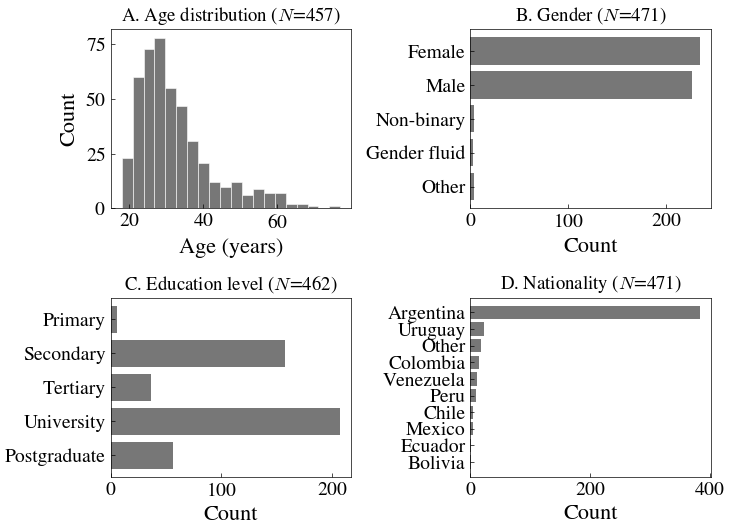

In [24]:
# ---------------------------------------------------------------------------
# Figure 1 — 2×2 demographics panel
# ---------------------------------------------------------------------------

EDU_ORDER  = ["P", "S", "T", "U", "R"]
EDU_LABELS = {
    "P": "Primary", "S": "Secondary", "T": "Tertiary",
    "U": "University", "R": "Postgraduate",
}
GENDER_ORDER = ["Female", "Male", "Non-binary", "Gender fluid", "Other"]

fig, axes = plt.subplots(2, 2, figsize=(7.5, 5.5))
(ax_a, ax_b), (ax_c, ax_d) = axes

# --- A. Age distribution ---
ages = metadata["age"].dropna()
ax_a.hist(ages, bins=20, color=C_DEMO, edgecolor="white", linewidth=0.4)
ax_a.set_xlabel("Age (years)")
ax_a.set_ylabel("Count")
ax_a.set_title(f"A. Age distribution ($N$={len(ages)})")

# --- B. Gender ---
present_genders = [g for g in GENDER_ORDER if g in metadata["gender_desc"].values]
gender_counts = metadata["gender_desc"].value_counts().reindex(present_genders)
ax_b.barh(gender_counts.index[::-1], gender_counts.values[::-1], color=C_DEMO)
ax_b.set_xlabel("Count")
ax_b.set_title(f"B. Gender ($N$={metadata['gender_desc'].notna().sum()})")

# --- C. Education level (ordered P→R) ---
present_edu = [e for e in EDU_ORDER if e in metadata["education_level"].values]
edu_counts  = metadata["education_level"].value_counts().reindex(present_edu)
edu_labels  = [EDU_LABELS[e] for e in edu_counts.index]
ax_c.barh(edu_labels[::-1], edu_counts.values[::-1], color=C_DEMO)
ax_c.set_xlabel("Count")
ax_c.set_title(f"C. Education level ($N$={metadata['education_level'].notna().sum()})")

# --- D. Nationality ---
nat_counts = metadata["nationality_clean"].value_counts()
ax_d.barh(nat_counts.index[::-1], nat_counts.values[::-1], color=C_DEMO)
ax_d.set_xlabel("Count")
ax_d.set_title(f"D. Nationality ($N$={metadata['nationality_clean'].notna().sum()})")

fig.tight_layout()
save_fig(fig, "fig1_demographics.png")
plt.show()

---
## Figure 2 — Performance Distributions

Five-panel violin plot: TMT completion time, TMT completion rate, visual working memory (CDT),
reactive inhibition (SST), and action restraint (Go/No-Go).

> **Requires:** Figure 1 data cell (loads `df_tmt`, `df_sst`, `df_cdt`, `df_gonogo`).

In [25]:
# ---------------------------------------------------------------------------
# Figure 2 — data preparation  (derived from already-loaded task DataFrames)
# ---------------------------------------------------------------------------

# TMT — extract part label
df_tmt_part = df_tmt.copy()
df_tmt_part["part"] = df_tmt_part["trial_type"].str.extract(r"(PART_[AB])")[0]
df_tmt_part = df_tmt_part.dropna(subset=["part"])

df_tmt_valid = df_tmt_part[df_tmt_part["is_valid"] == True].copy()
df_tmt_valid["time_sec"] = df_tmt_valid["non_cut_rt"] / 1000

# N=368: subjects with at least one valid trial in BOTH Part A AND Part B
sids_a    = set(df_tmt_valid[df_tmt_valid["part"] == "PART_A"]["subject_id"])
sids_b    = set(df_tmt_valid[df_tmt_valid["part"] == "PART_B"]["subject_id"])
sids_both = sids_a & sids_b
print(f"TMT N (valid in both parts): {len(sids_both)}")

# A. Mean completion time — restricted to sids_both
tmt_time = (
    df_tmt_valid[df_tmt_valid["subject_id"].isin(sids_both)]
    .groupby(["subject_id", "part"])["time_sec"]
    .mean()
    .reset_index()
)
tmt_time["Part"] = tmt_time["part"].map({"PART_A": "Part A", "PART_B": "Part B"})

# B. Percentage of valid trials — restricted to sids_both
tmt_pct = (
    df_tmt_part[df_tmt_part["subject_id"].isin(sids_both)]
    .groupby(["subject_id", "part"])
    .agg(total=("is_valid", "count"), valid=("is_valid", "sum"))
    .reset_index()
)
tmt_pct["pct_valid"] = 100 * tmt_pct["valid"] / tmt_pct["total"]
tmt_pct["Part"] = tmt_pct["part"].map({"PART_A": "Part A", "PART_B": "Part B"})

# C. CDT — long format K_4 / K_6
cdt_long = pd.melt(
    df_cdt[["subject_id", "K_4", "K_6"]],
    id_vars="subject_id",
    value_vars=["K_4", "K_6"],
    var_name="Set Size",
    value_name="K",
)
cdt_long["Set Size"] = cdt_long["Set Size"].map({"K_4": "$K_4$", "K_6": "$K_6$"})

print("Figure 2 data ready.")


TMT N (valid in both parts): 368
Figure 2 data ready.


/tmp/ipykernel_75411/2575033520.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_a.set_xticklabels(["Part A", "Part B"], fontsize=TICK_FS)
/tmp/ipykernel_75411/2575033520.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_b.set_xticklabels(["Part A", "Part B"], fontsize=TICK_FS)
/tmp/ipykernel_75411/2575033520.py:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_c.set_xticklabels(["$K_4$", "$K_6$"], fontsize=TICK_FS)


Saved -> /home/gus/Documents/REPOS/datapruebas_analysis/figures/fig2_performance_distributions.png


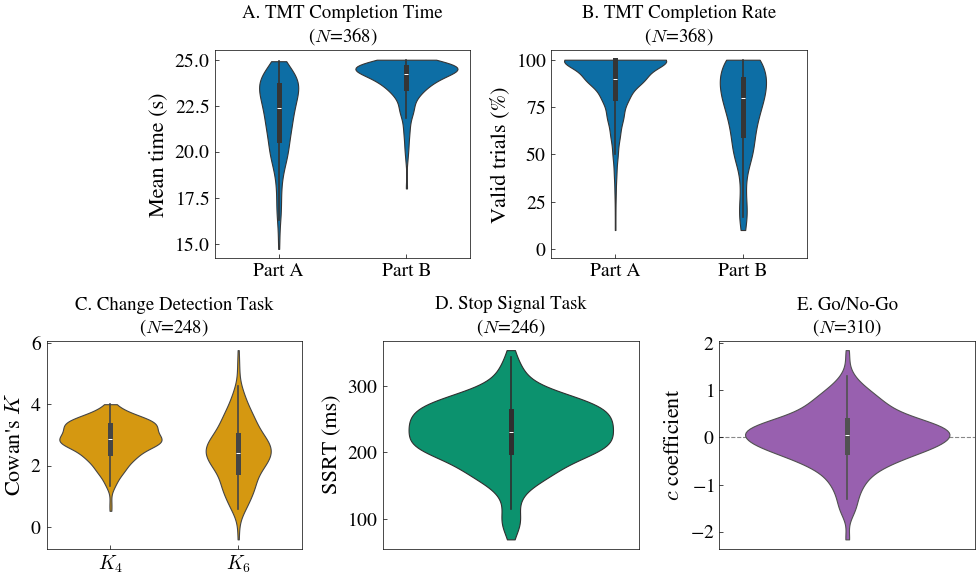

In [26]:
# ---------------------------------------------------------------------------
# Figure 2 — five-panel violin plot
# ---------------------------------------------------------------------------

# One color per task
C_TMT    = C_BLUE    # panels A & B
C_CDT    = C_AMBER   # panel C
C_SST    = C_TEAL    # panel D
C_GONOGO = C_PURPLE  # panel E

fig = plt.figure(figsize=(10, 6))
gs  = gridspec.GridSpec(2, 6, figure=fig)

# Top row: 2 TMT panels centered (offset 1 col each side)
ax_a = fig.add_subplot(gs[0, 1:3])
ax_b = fig.add_subplot(gs[0, 3:5])

# Bottom row: 3 panels spanning 2 columns each
ax_c = fig.add_subplot(gs[1, 0:2])
ax_d = fig.add_subplot(gs[1, 2:4])
ax_e = fig.add_subplot(gs[1, 4:6])

# --- A. TMT Completion Time ---
sns.violinplot(data=tmt_time, x="Part", y="time_sec", ax=ax_a, **VIOLIN_KW, color=C_TMT)
ax_a.set_title(f"A. TMT Completion Time\n($N$={tmt_time['subject_id'].nunique()})")
ax_a.set_ylabel("Mean time (s)")
ax_a.set_xlabel("")
ax_a.set_xticklabels(["Part A", "Part B"], fontsize=TICK_FS)

# --- B. TMT Completion Rate ---
sns.violinplot(data=tmt_pct, x="Part", y="pct_valid", ax=ax_b, **VIOLIN_KW, color=C_TMT)
ax_b.set_title(f"B. TMT Completion Rate\n($N$={tmt_pct['subject_id'].nunique()})")
ax_b.set_ylabel("Valid trials (%)")
ax_b.set_xlabel("")
ax_b.set_ylim(-5, 105)
ax_b.set_xticklabels(["Part A", "Part B"], fontsize=TICK_FS)

# --- C. Change Detection Task (CDT) ---
sns.violinplot(data=cdt_long, x="Set Size", y="K", ax=ax_c, **VIOLIN_KW, color=C_CDT)
ax_c.set_title(f"C. Change Detection Task\n($N$={df_cdt['subject_id'].nunique()})")
ax_c.set_ylabel("Cowan's $K$")
ax_c.set_xlabel("")
ax_c.set_xticklabels(["$K_4$", "$K_6$"], fontsize=TICK_FS)

# --- D. Stop Signal Task (SST) ---
sns.violinplot(data=df_sst, y="ssrt", ax=ax_d, **VIOLIN_KW, color=C_SST)
ax_d.set_title(f"D. Stop Signal Task\n($N$={len(df_sst)})")
ax_d.set_ylabel("SSRT (ms)")
ax_d.set_xlabel("")
ax_d.set_xticks([])

# --- E. Go/No-Go — c coefficient ---
sns.violinplot(data=df_gonogo, y="c", ax=ax_e, **VIOLIN_KW, color=C_GONOGO)
ax_e.axhline(0, color=C_GRAY, ls="--", lw=0.8, zorder=0)
ax_e.set_title(f"E. Go/No-Go\n($N$={len(df_gonogo)})")
ax_e.set_ylabel("$c$ coefficient")
ax_e.set_xlabel("")
ax_e.set_xticks([])

apply_style([ax_a, ax_b, ax_c, ax_d, ax_e])
fig.tight_layout()
save_fig(fig, "fig2_performance_distributions.png")
plt.show()


---
## Figure 3 — SHAP Feature Importance

Five-panel horizontal bar plot showing mean |SHAP| for the top predictive features
across the significant models for each cognitive target.

Layout: A+B (top) / C+D (middle) / E centered (bottom).

> **Note:** The first run computes SHAP values by re-fitting each model per LOO fold —
> this can take several minutes per panel. Results are cached to CSV automatically;
> subsequent runs load instantly.

In [27]:
# ---------------------------------------------------------------------------
# Figure 3 — SHAP data loading
# ---------------------------------------------------------------------------

from src.model.shap.run_shap import run_shap
from src.model.shap.analyze_shap_results import analyze_shap_results, build_mean_shap_df
from src.model.run_models import retrieve_dataset

# Feature labels — exact copy from src/model/shap/analyze_shap_results.py
FEATURE_LABELS = {
    "is_valid_sum_A": "Valid sum (Part A)",
    "is_valid_sum_B": "Valid sum (Part B)",

    "area_difference_from_ideal_PART_A": "Area difference from ideal (Part A)",
    "area_difference_from_ideal_PART_B": "Area difference from ideal (Part B)",
    "area_difference_from_ideal_B_A_ratio": "Area difference from ideal (B/A ratio)",

    "average_duration_PART_A": "Average duration (Part A)",
    "average_duration_PART_B": "Average duration (Part B)",
    "average_duration_B_A_ratio": "Average duration (B/A ratio)",

    "distance_difference_from_ideal_PART_A": "Distance difference from ideal (Part A)",
    "distance_difference_from_ideal_PART_B": "Distance difference from ideal (Part B)",
    "distance_difference_from_ideal_B_A_ratio": "Distance difference from ideal (B/A ratio)",

    "hesitation_avg_speed_PART_A": "Hesitation average speed (Part A)",
    "hesitation_avg_speed_PART_B": "Hesitation average speed (Part B)",
    "hesitation_avg_speed_B_A_ratio": "Hesitation average speed (B/A ratio)",

    "hesitation_distance_PART_A": "Hesitation distance (Part A)",
    "hesitation_distance_PART_B": "Hesitation distance (Part B)",
    "hesitation_distance_B_A_ratio": "Hesitation distance (B/A ratio)",

    "hesitation_time_PART_A": "Hesitation time (Part A)",
    "hesitation_time_PART_B": "Hesitation time (Part B)",
    "hesitation_time_B_A_ratio": "Hesitation time (B/A ratio)",

    "inter_target_time_PART_A": "Inter-target time (Part A)",
    "inter_target_time_PART_B": "Inter-target time (Part B)",
    "inter_target_time_B_A_ratio": "Inter-target time (B/A ratio)",

    "intra_target_time_PART_A": "Intra-target time (Part A)",
    "intra_target_time_PART_B": "Intra-target time (Part B)",
    "intra_target_time_B_A_ratio": "Intra-target time (B/A ratio)",

    "max_duration_PART_A": "Hesitation max duration (Part A)",
    "max_duration_PART_B": "Hesitation max duration (Part B)",
    "max_duration_B_A_ratio": "Hesitation max duration (B/A ratio)",

    "mean_abs_acceleration_PART_A": "Mean absolute acceleration (Part A)",
    "mean_abs_acceleration_PART_B": "Mean absolute acceleration (Part B)",
    "mean_abs_acceleration_B_A_ratio": "Mean absolute acceleration (B/A ratio)",

    "mean_acceleration_PART_A": "Mean acceleration (Part A)",
    "mean_acceleration_PART_B": "Mean acceleration (Part B)",
    "mean_acceleration_B_A_ratio": "Mean acceleration (B/A ratio)",

    "mean_negative_acceleration_PART_A": "Mean negative acceleration (Part A)",
    "mean_negative_acceleration_PART_B": "Mean negative acceleration (Part B)",
    "mean_negative_acceleration_B_A_ratio": "Mean negative acceleration (B/A ratio)",

    "mean_speed_PART_A": "Mean speed (Part A)",
    "mean_speed_PART_B": "Mean speed (Part B)",
    "mean_speed_B_A_ratio": "Mean speed (B/A ratio)",

    "non_cut_correct_targets_touches_PART_A": "Complete correct touches (Part A)",
    "non_cut_correct_targets_touches_PART_B": "Complete correct touches (Part B)",
    "non_cut_correct_targets_touches_B_A_ratio": "Complete correct touches (B/A ratio)",

    "non_cut_rt_PART_A": "Complete time in trial (Part A)",
    "non_cut_rt_PART_B": "Complete time in trial (Part B)",
    "non_cut_rt_B_A_ratio": "Complete time in trial (B/A ratio)",

    "peak_abs_acceleration_PART_A": "Peak absolute acceleration (Part A)",
    "peak_abs_acceleration_PART_B": "Peak absolute acceleration (Part B)",
    "peak_abs_acceleration_B_A_ratio": "Peak absolute acceleration (B/A ratio)",

    "peak_acceleration_PART_A": "Peak acceleration (Part A)",
    "peak_acceleration_PART_B": "Peak acceleration (Part B)",
    "peak_acceleration_B_A_ratio": "Peak acceleration (B/A ratio)",

    "peak_negative_acceleration_PART_A": "Peak negative acceleration (Part A)",
    "peak_negative_acceleration_PART_B": "Peak negative acceleration (Part B)",
    "peak_negative_acceleration_B_A_ratio": "Peak negative acceleration (B/A ratio)",

    "peak_speed_PART_A": "Peak speed (Part A)",
    "peak_speed_PART_B": "Peak speed (Part B)",
    "peak_speed_B_A_ratio": "Peak speed (B/A ratio)",

    "rt_PART_A": "Time in trial (Part A)",
    "rt_PART_B": "Time in trial (Part B)",
    "rt_B_A_ratio": "Time in trial (B/A ratio)",

    "search_avg_speed_PART_A": "Search average speed (Part A)",
    "search_avg_speed_PART_B": "Search average speed (Part B)",
    "search_avg_speed_B_A_ratio": "Search average speed (B/A ratio)",

    "search_distance_PART_A": "Search distance (Part A)",
    "search_distance_PART_B": "Search distance (Part B)",
    "search_distance_B_A_ratio": "Search distance (B/A ratio)",

    "search_time_PART_A": "Search time (Part A)",
    "search_time_PART_B": "Search time (Part B)",
    "search_time_B_A_ratio": "Search time (B/A ratio)",

    "state_transitions_PART_A": "State transitions (Part A)",
    "state_transitions_PART_B": "State transitions (Part B)",
    "state_transitions_B_A_ratio": "State transitions (B/A ratio)",

    "std_abs_acceleration_PART_A": "STD absolute acceleration (Part A)",
    "std_abs_acceleration_PART_B": "STD absolute acceleration (Part B)",
    "std_abs_acceleration_B_A_ratio": "STD absolute acceleration (B/A ratio)",

    "std_acceleration_PART_A": "STD acceleration (Part A)",
    "std_acceleration_PART_B": "STD acceleration (Part B)",
    "std_acceleration_B_A_ratio": "STD acceleration (B/A ratio)",

    "std_negative_acceleration_PART_A": "STD negative acceleration (Part A)",
    "std_negative_acceleration_PART_B": "STD negative acceleration (Part B)",
    "std_negative_acceleration_B_A_ratio": "STD negative acceleration (B/A ratio)",

    "std_speed_PART_A": "STD speed (Part A)",
    "std_speed_PART_B": "STD speed (Part B)",
    "std_speed_B_A_ratio": "STD speed (B/A ratio)",

    "total_distance_PART_A": "Total distance (Part A)",
    "total_distance_PART_B": "Total distance (Part B)",
    "total_distance_B_A_ratio": "Total distance (B/A ratio)",

    "total_hesitations_PART_A": "Hesitations (Part A)",
    "total_hesitations_PART_B": "Hesitations (Part B)",
    "total_hesitations_B_A_ratio": "Hesitations (B/A ratio)",

    "travel_avg_speed_PART_A": "Travel average speed (Part A)",
    "travel_avg_speed_PART_B": "Travel average speed (Part B)",
    "travel_avg_speed_B_A_ratio": "Travel average speed (B/A ratio)",

    "travel_distance_PART_A": "Travel distance (Part A)",
    "travel_distance_PART_B": "Travel distance (Part B)",
    "travel_distance_B_A_ratio": "Travel distance (B/A ratio)",

    "travel_time_PART_A": "Travel time (Part A)",
    "travel_time_PART_B": "Travel time (Part B)",
    "travel_time_B_A_ratio": "Travel time (B/A ratio)",

    "age": "Age",

    "wrong_targets_touches_PART_A":           "Wrong target touches (Part A)",
    "wrong_targets_touches_PART_B":           "Wrong target touches (Part B)",
    "wrong_targets_touches_B_A_ratio":        "Wrong target touches (B/A ratio)",

    "scale_factor_PART_A":                    "Scale factor (Part A)",
    "scale_factor_PART_B":                    "Scale factor (Part B)",
    "scale_factor_B_A_ratio":                 "Scale factor (B/A ratio)",

    "number_of_crosses_PART_A":               "Number of crosses (Part A)",
    "number_of_crosses_PART_B":               "Number of crosses (Part B)",
    "number_of_crosses_B_A_ratio":            "Number of crosses (B/A ratio)",

    "sample_count_PART_A":                    "Sample count (Part A)",
    "sample_count_PART_B":                    "Sample count (Part B)",
    "sample_count_B_A_ratio":                 "Sample count (B/A ratio)",

    "valid_interval_count_PART_A":            "Valid interval count (Part A)",
    "valid_interval_count_PART_B":            "Valid interval count (Part B)",
    "valid_interval_count_B_A_ratio":         "Valid interval count (B/A ratio)",

    "non_cut_search_distance_PART_A":         "Complete search distance (Part A)",
    "non_cut_search_distance_PART_B":         "Complete search distance (Part B)",
    "non_cut_search_distance_B_A_ratio":      "Complete search distance (B/A ratio)",

    "non_cut_total_distance_PART_A":          "Complete total distance (Part A)",
    "non_cut_total_distance_PART_B":          "Complete total distance (Part B)",
    "non_cut_total_distance_B_A_ratio":       "Complete total distance (B/A ratio)",

    "non_cut_intra_target_time_PART_A":       "Complete intra-target time (Part A)",
    "non_cut_intra_target_time_PART_B":       "Complete intra-target time (Part B)",
    "non_cut_intra_target_time_B_A_ratio":    "Complete intra-target time (B/A ratio)",

    "non_cut_inter_target_time_PART_A":       "Complete inter-target time (Part A)",
    "non_cut_inter_target_time_PART_B":       "Complete inter-target time (Part B)",
    "non_cut_inter_target_time_B_A_ratio":    "Complete inter-target time (B/A ratio)",

    "non_cut_search_avg_speed_PART_A":        "Complete search average speed (Part A)",
    "non_cut_search_avg_speed_PART_B":        "Complete search average speed (Part B)",
    "non_cut_search_avg_speed_B_A_ratio":     "Complete search average speed (B/A ratio)",

    "non_cut_mean_speed_PART_A":              "Complete mean speed (Part A)",
    "non_cut_mean_speed_PART_B":              "Complete mean speed (Part B)",
    "non_cut_mean_speed_B_A_ratio":           "Complete mean speed (B/A ratio)",

    "non_cut_state_transitions_PART_A":       "Complete state transitions (Part A)",
    "non_cut_state_transitions_PART_B":       "Complete state transitions (Part B)",
    "non_cut_state_transitions_B_A_ratio":    "Complete state transitions (B/A ratio)",

    "non_cut_search_time_PART_A":             "Complete search time (Part A)",
    "non_cut_search_time_PART_B":             "Complete search time (Part B)",
    "non_cut_search_time_B_A_ratio":          "Complete search time (B/A ratio)",

    "non_cut_number_of_crosses_PART_A":       "Complete number of crosses (Part A)",
    "non_cut_number_of_crosses_PART_B":       "Complete number of crosses (Part B)",
    "non_cut_number_of_crosses_B_A_ratio":    "Complete number of crosses (B/A ratio)",
}


def load_or_compute_shap(dataset_name, model, timestamp, task="regression"):
    """Load pre-computed SHAP CSV if available, otherwise compute and cache it."""
    _, _, _, target_name = retrieve_dataset(dataset_name)
    csv_path = os.path.join(
        PROJECT_ROOT, "results", task, timestamp, target_name, dataset_name,
        f"shap_values_{model}.csv"
    )
    if os.path.exists(csv_path):
        print(f"  [{dataset_name}/{model}] Loading from cache: {csv_path}")
        raw = pd.read_csv(csv_path)
        feat_cols = [c for c in raw.columns if c not in ("fold", "base_value")]
        return build_mean_shap_df(raw[feat_cols].abs())
    else:
        print(f"  [{dataset_name}/{model}] Computing SHAP (may take several minutes)...")
        explanations, _ = run_shap(
            task=task, dataset_name=dataset_name,
            timestamp=timestamp, model_name_to_explain=model
        )
        return analyze_shap_results(explanations, task=task)


# Panels definition: (subplot label, dataset, model, timestamp)
SHAP_COMBOS = [
    ("A. Age — SVR",                "tmt_age",      "SVR",          "2026-02-03_2053"),
    ("B. $K_{mean}$ — XGBRegressor","tmt_k_mean",   "XGBRegressor", "2026-02-03_2053"),
    ("C. Accuracy — Ridge",         "tmt_accuracy", "Ridge",        "2026-02-05_2206"),
    ("D. $c$ coefficient — Ridge",  "tmt_c",        "Ridge",        "2026-02-07_0100"),
]

print("Loading SHAP data...")
shap_dfs = []
for label, dataset, model, ts in SHAP_COMBOS:
    df = load_or_compute_shap(dataset, model, ts)
    shap_dfs.append(df)
    print(f"  Done: {label}")

print("\nAll SHAP data ready.")


Loading SHAP data...


  [tmt_age/SVR] Loading from cache: /home/gus/Documents/REPOS/datapruebas_analysis/results/regression/2026-02-03_2053/age/tmt_age/shap_values_SVR.csv
  Done: A. Age — SVR


  [tmt_k_mean/XGBRegressor] Loading from cache: /home/gus/Documents/REPOS/datapruebas_analysis/results/regression/2026-02-03_2053/K_mean/tmt_k_mean/shap_values_XGBRegressor.csv
  Done: B. $K_{mean}$ — XGBRegressor


  [tmt_accuracy/Ridge] Loading from cache: /home/gus/Documents/REPOS/datapruebas_analysis/results/regression/2026-02-05_2206/accuracy/tmt_accuracy/shap_values_Ridge.csv
  Done: C. Accuracy — Ridge
  [tmt_c/Ridge] Loading from cache: /home/gus/Documents/REPOS/datapruebas_analysis/results/regression/2026-02-07_0100/c/tmt_c/shap_values_Ridge.csv
  Done: D. $c$ coefficient — Ridge

All SHAP data ready.


Saved -> /home/gus/Documents/REPOS/datapruebas_analysis/figures/fig3_shap_importance.png


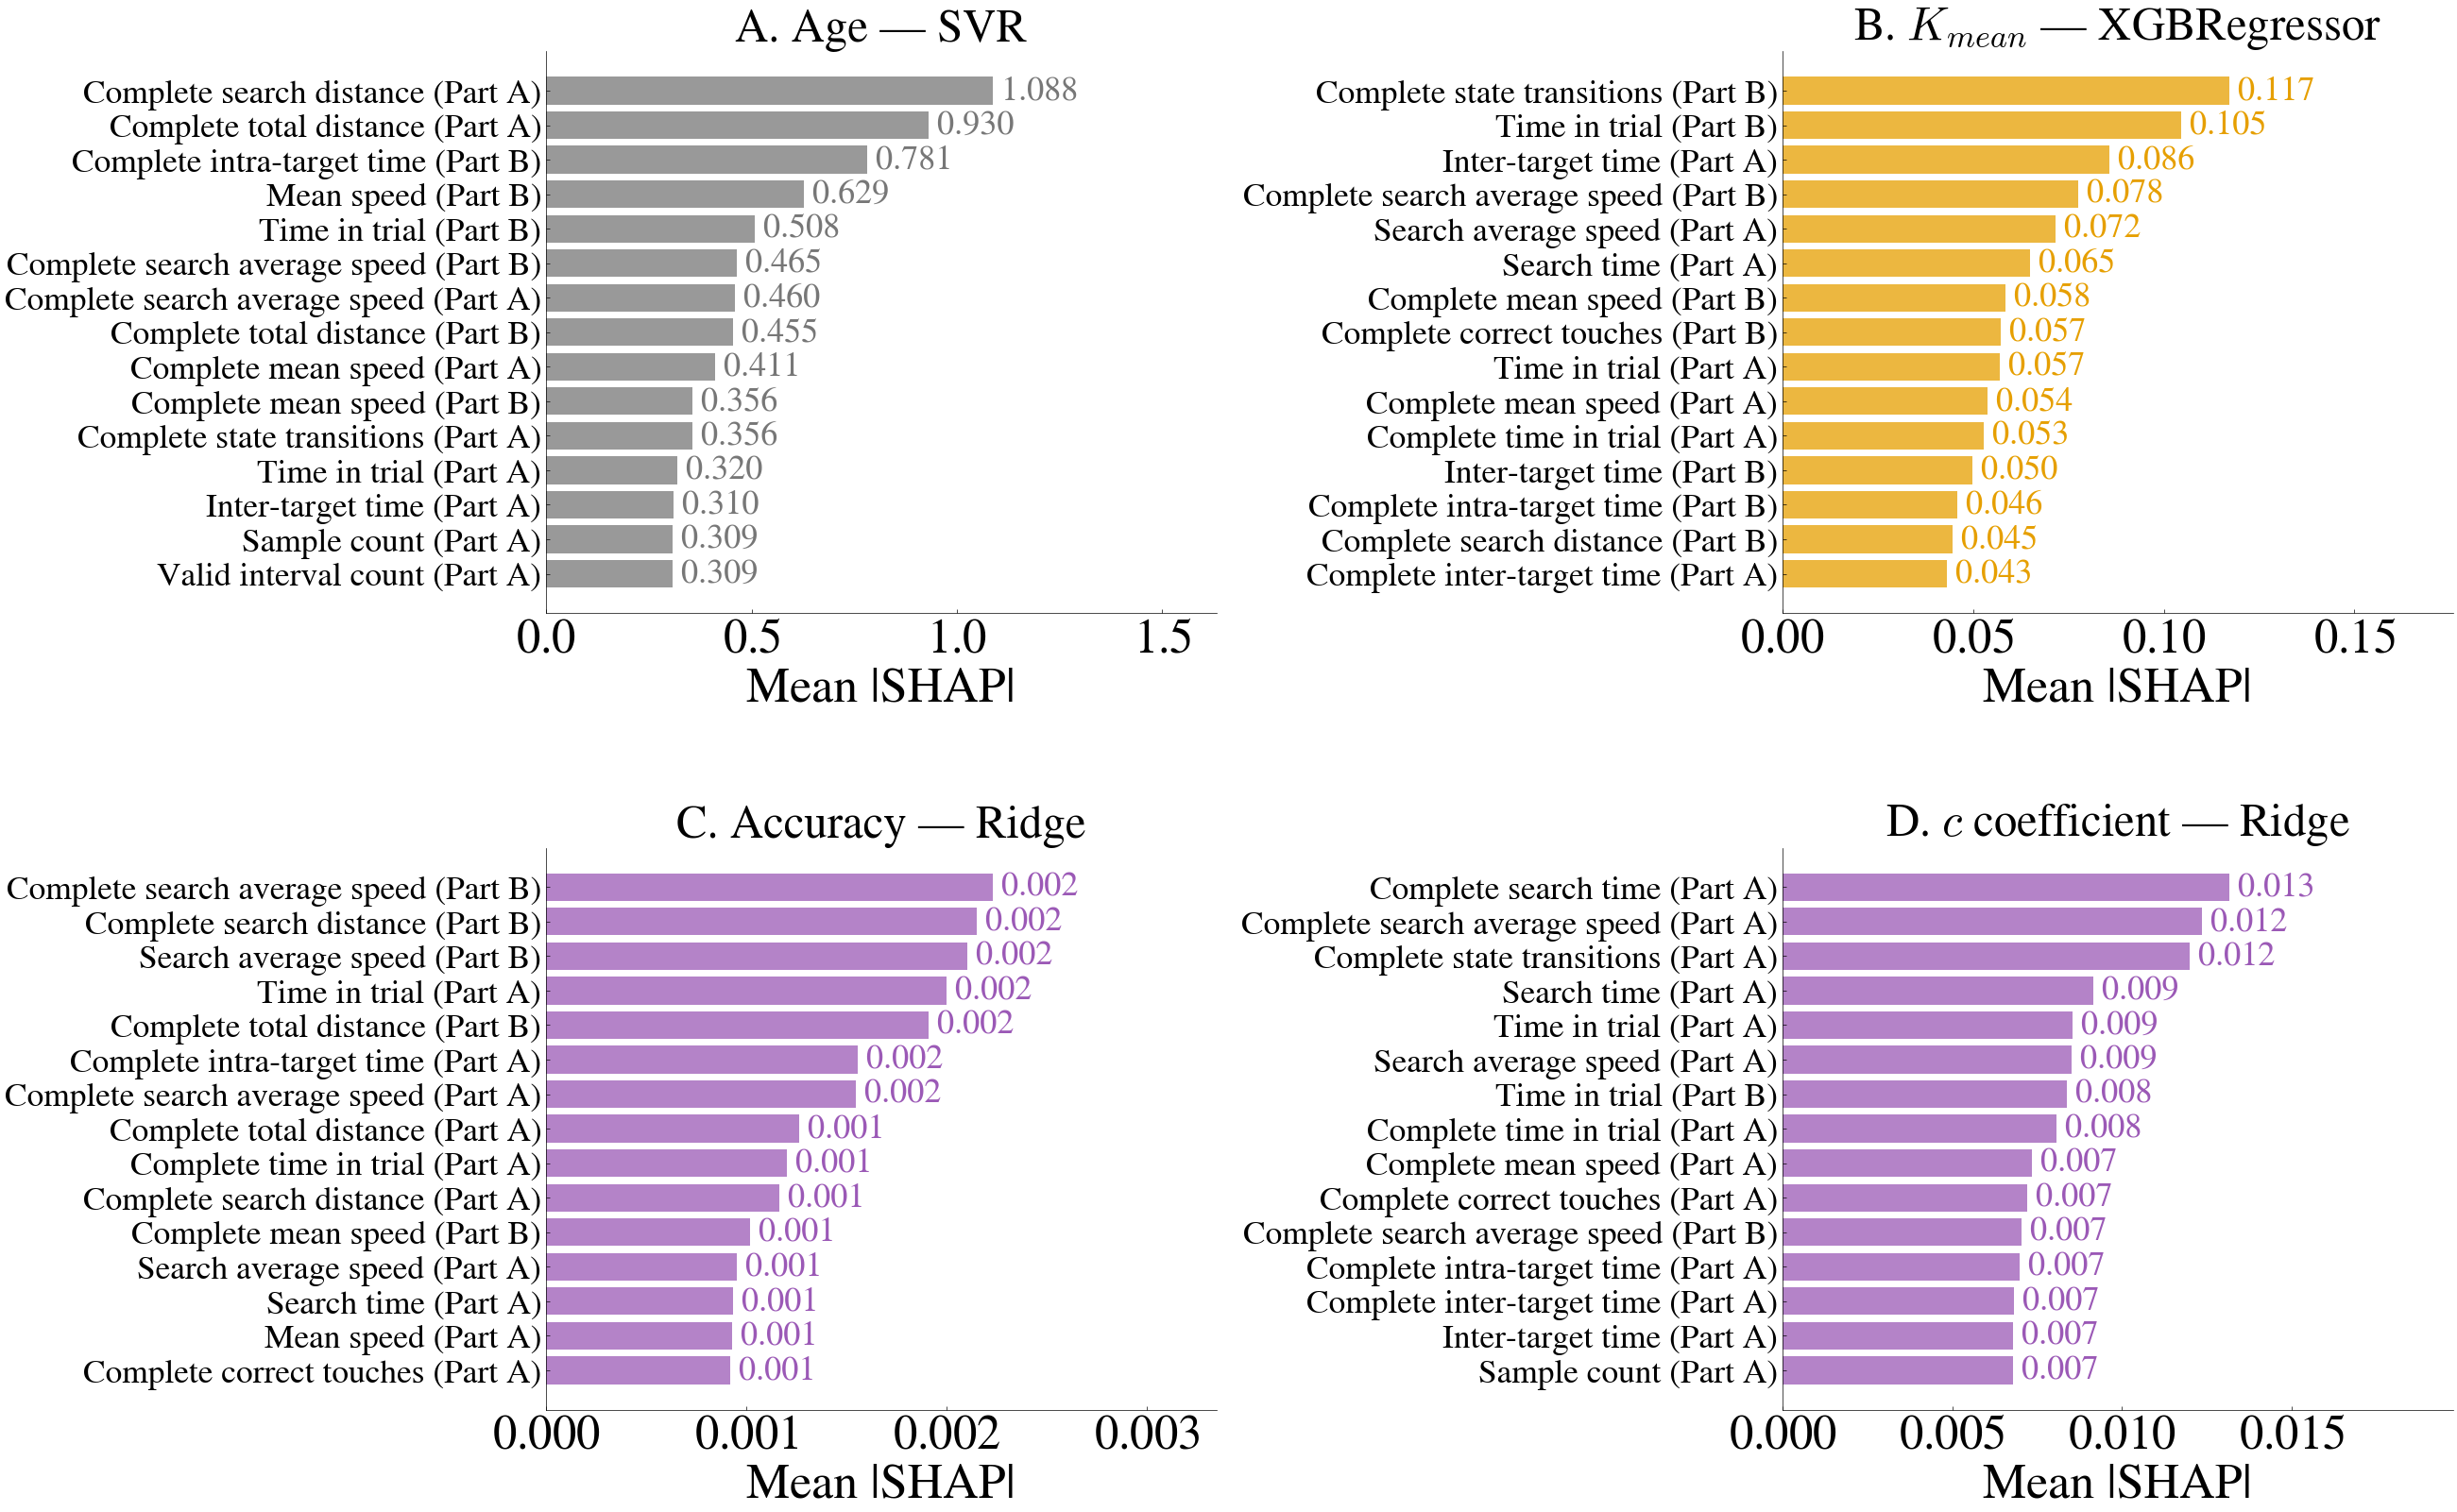

In [28]:
# ---------------------------------------------------------------------------
# Figure 3 — four-panel SHAP feature importance (2×2 layout)
# ---------------------------------------------------------------------------

TOP_N = 15  # features shown per panel

_FIG_W  = 26
_FIG_H  = 16
_BASE_W = 10
_S = _FIG_W / _BASE_W  # = 2.6

_TITLE_FS = TITLE_FS * _S
_LABEL_FS = LABEL_FS * _S
_TICK_FS  = TICK_FS  * _S
_ANNOT_FS = ANNOT_FS * _S
_YTICK_FS = TICK_FS  * _S * 0.7

# Panels: (label, dataset, model, timestamp, bar_color)
# Color = task of the TARGET variable (same palette as Figure 2)
SHAP_COMBOS_PLOT = [
    ("A. Age — SVR",                "tmt_age",      "SVR",          "2026-02-03_2053", C_DEMO),
    ("B. $K_{mean}$ — XGBRegressor","tmt_k_mean",   "XGBRegressor", "2026-02-03_2053", C_AMBER),
    ("C. Accuracy — Ridge",         "tmt_accuracy", "Ridge",        "2026-02-05_2206", C_PURPLE),
    ("D. $c$ coefficient — Ridge",  "tmt_c",        "Ridge",        "2026-02-07_0100", C_PURPLE),
]

fig = plt.figure(figsize=(_FIG_W, _FIG_H), constrained_layout=True)
fig.set_constrained_layout_pads(hspace=0.12)
gs  = gridspec.GridSpec(2, 2, figure=fig)

ax_a = fig.add_subplot(gs[0, 0])
ax_b = fig.add_subplot(gs[0, 1])
ax_c = fig.add_subplot(gs[1, 0])
ax_d = fig.add_subplot(gs[1, 1])

panel_axes = [ax_a, ax_b, ax_c, ax_d]

for ax, (panel_label, dataset, model, ts, color), shap_df in zip(panel_axes, SHAP_COMBOS_PLOT, shap_dfs):
    df_plot = shap_df.sort_values("mean_abs_shap", ascending=True).tail(TOP_N)
    df_plot.index = df_plot.index.map(lambda x: FEATURE_LABELS.get(x, x))

    bars = ax.barh(df_plot.index, df_plot["mean_abs_shap"], color=color, alpha=0.75)

    max_val = df_plot["mean_abs_shap"].max()
    for bar in bars:
        w = bar.get_width()
        ax.text(w, bar.get_y() + bar.get_height() / 2,
                f" {w:.3f}", va="center", ha="left",
                fontsize=_ANNOT_FS, color=color)
    ax.set_xlim(0, max_val * 1.5)

    ax.set_title(panel_label, fontsize=_TITLE_FS)
    ax.set_xlabel("Mean |SHAP|", fontsize=_LABEL_FS*0.9)
    ax.set_ylabel("")
    ax.tick_params(axis="y", labelsize=_YTICK_FS)
    ax.tick_params(axis="x", labelsize=_TICK_FS)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

save_fig(fig, "fig3_shap_importance.png")
plt.show()


Selected: subject=3d00f43e-3c2f-44bc-91a4-618f785fb778  trial=DATAPRUEBAS_19  hesitations=10


ERROR:root:Error processing experiment for subject f7031def-b705-41e7-aa54-da7e0c4ee601
Traceback (most recent call last):
  File "/home/gus/Documents/REPOS/datapruebas_analysis/src/mapper/datapruebas/datapruebas_mapper.py", line 64, in map_to_experiment
    subjects[experiment.subject_id] = self.map_to_subject(experiment.records[0], start_date)
  File "/home/gus/Documents/REPOS/datapruebas_analysis/src/mapper/datapruebas/datapruebas_mapper.py", line 94, in map_to_subject
    raise ValueError("Subject must have both training and testing stimuli")
ValueError: Subject must have both training and testing stimuli


Mapping 127 subjects...


ERROR:root:Error processing experiment for subject c890dfc5-aea9-4f93-833e-988009c44d71
Traceback (most recent call last):
  File "/home/gus/Documents/REPOS/datapruebas_analysis/src/mapper/datapruebas/datapruebas_mapper.py", line 64, in map_to_experiment
    subjects[experiment.subject_id] = self.map_to_subject(experiment.records[0], start_date)
  File "/home/gus/Documents/REPOS/datapruebas_analysis/src/mapper/datapruebas/datapruebas_mapper.py", line 94, in map_to_subject
    raise ValueError("Subject must have both training and testing stimuli")
ValueError: Subject must have both training and testing stimuli
ERROR:root:Error processing experiment for subject 139efc97-c335-401c-a98f-dd3825ab2d87
Traceback (most recent call last):
  File "/home/gus/Documents/REPOS/datapruebas_analysis/src/mapper/datapruebas/datapruebas_mapper.py", line 64, in map_to_experiment
    subjects[experiment.subject_id] = self.map_to_subject(experiment.records[0], start_date)
  File "/home/gus/Documents/REPOS/d

Mapped 58 valid subjects.
Saved -> /home/gus/Documents/REPOS/datapruebas_analysis/figures/fig4_tmt_segmentation.png
Saved -> /home/gus/Documents/REPOS/datapruebas_analysis/figures/fig4_tmt_segmentation.svg


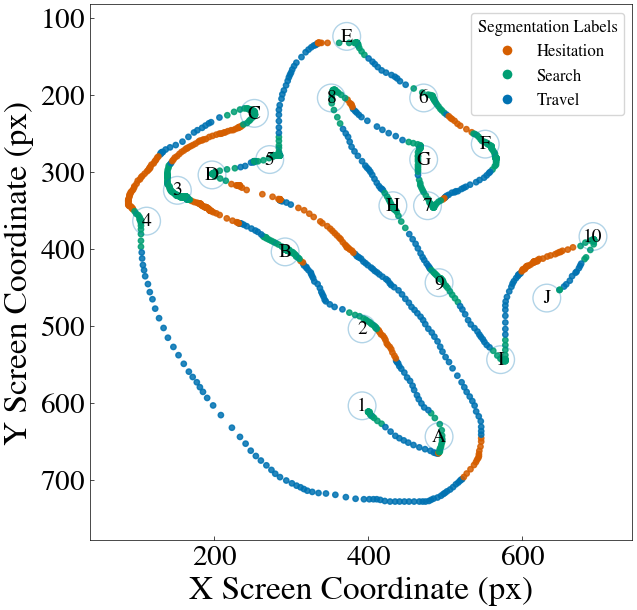

In [31]:
# ---------------------------------------------------------------------------
# Figure 4 — TMT trail segmentation (single representative trial)
# ---------------------------------------------------------------------------

from src.mapper.datapruebas.datapruebas_mapper import DatapruebasTMTMapper
from src import config
from neurotask.tmt.segmentation.segmentation import classify_cursor_positions_with_hesitation
from src.visualization.trial_plotting_helpers import draw_trial_targets, configure_trial_axes

_S4 = 1.5  # font scale factor for this figure

# Okabe-Ito colors per segment type
SEG_COLORS = {
    "Hesitation": C_ORANGE,   # D55E00
    "Search":     C_TEAL,     # 009E73
    "Travel":     C_BLUE,     # 0072B2
}

# --- Pick a visually interesting PART_B trial ---
df_cand = df_tmt[
    (df_tmt["is_valid"] == True) &
    (df_tmt["trial_type"].str.contains("PART_B")) &
    (df_tmt["trial_id"].str.startswith("DATAPRUEBAS")) &
    (df_tmt["non_cut_correct_targets_touches"] >= 20) &
    (df_tmt["total_hesitations"] >= 5)
].copy()

row = df_cand.sort_values("total_hesitations", ascending=False).iloc[5]
target_subject_id = row["subject_id"]
target_trial_id   = row["trial_id"]
speed_threshold   = row["speed_threshold"]
print(f"Selected: subject={target_subject_id}  trial={target_trial_id}  hesitations={row['total_hesitations']:.0f}")

# --- Load raw experiment ---
dataset_path = os.path.join(
    PROJECT_ROOT, "data", "raw", "tmt", "datapruebas", "subjects",
    config.EXPERIMENT_FILE_NAME
)
experiment = DatapruebasTMTMapper().map(dataset_path)

subject = experiment.subjects[target_subject_id]
trial   = next(t for t in subject.testing_trials if t.id == target_trial_id)

# --- Segment the cursor trail ---
segmentation = classify_cursor_positions_with_hesitation(
    trial, subject.target_radius, config.TARGET_RADIUS_MULTIPLIER, speed_threshold
)
labels = [label for (label, _) in segmentation]

cursor_trail = trial.get_cursor_trail_from_start()
cursor_x = [p.position.x for p in cursor_trail]
cursor_y = [p.position.y for p in cursor_trail]
point_colors = [SEG_COLORS.get(l, C_GRAY) for l in labels]

# --- Plot ---
fig, ax = plt.subplots(figsize=(7, 7))

ax.scatter(cursor_x, cursor_y, c=point_colors, s=15, zorder=4, alpha=0.85)
draw_trial_targets(ax, trial, subject.target_radius, circle_color=C_BLUE,
                   text_fontsize=round(9 * _S4))
configure_trial_axes(ax, x=cursor_x, y=cursor_y, show_labels=True,
                     xlabel="X Screen Coordinate (px)", ylabel="Y Screen Coordinate (px)")

handles = [
    plt.Line2D([0], [0], marker='o', color='w', label=k,
               markerfacecolor=v, markersize=8)
    for k, v in SEG_COLORS.items()
]
ax.legend(handles=handles, title="Segmentation Labels", frameon=True,
          fontsize=LEGEND_FS, title_fontsize=LEGEND_FS)
# ax.set_title("TMT Trail Extraction & Segmentation")

# --- Scale all text 1.5x (except legend) ---
# ax.title.set_fontsize(TITLE_FS * _S4)
ax.xaxis.label.set_fontsize(LABEL_FS * _S4)
ax.yaxis.label.set_fontsize(LABEL_FS * _S4)
ax.tick_params(axis="both", labelsize=TICK_FS * _S4)

# Save as PNG (paper) and SVG (slides — scales without quality loss)
save_fig(fig, "fig4_tmt_segmentation.png")
fig.savefig(os.path.join(FIGURES_DIR, "fig4_tmt_segmentation.svg"), format="svg", bbox_inches="tight")
print(f"Saved -> {os.path.join(FIGURES_DIR, 'fig4_tmt_segmentation.svg')}")

plt.show()
